<a href="https://colab.research.google.com/github/madhuvanthi-l-20/POWER-BI-SALES-DASHBOARD/blob/main/Python_project_Student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving StudentsPerformance.csv to StudentsPerformance.csv
['ArrowDtype', 'BooleanDtype', 'Categorical', 'CategoricalDtype', 'CategoricalIndex', 'DataFrame', 'DateOffset', 'DatetimeIndex', 'DatetimeTZDtype', 'ExcelFile', 'ExcelWriter', 'Flags', 'Float32Dtype', 'Float64Dtype', 'Grouper', 'HDFStore', 'Index', 'IndexSlice', 'Int16Dtype', 'Int32Dtype', 'Int64Dtype', 'Int8Dtype', 'Interval', 'IntervalDtype', 'IntervalIndex', 'MultiIndex', 'NA', 'NaT', 'NamedAgg', 'Period', 'PeriodDtype', 'PeriodIndex', 'RangeIndex', 'Series', 'SparseDtype', 'StringDtype', 'Timedelta', 'TimedeltaIndex', 'Timestamp', 'UInt16Dtype', 'UInt32Dtype', 'UInt64Dtype', 'UInt8Dtype', '__all__', '__builtins__', '__cached__', '__doc__', '__docformat__', '__file__', '__git_version__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_built_with_meson', '_config', '_is_numpy_dev', '_libs', '_pandas_datetime_CAPI', '_pandas_parser_CAPI', '_testing', '_typing', '_version_meson', 'annotations',

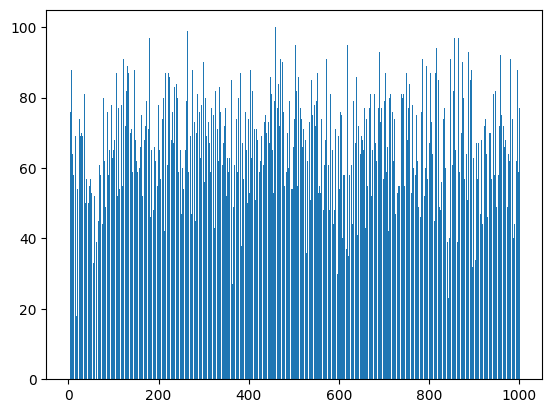

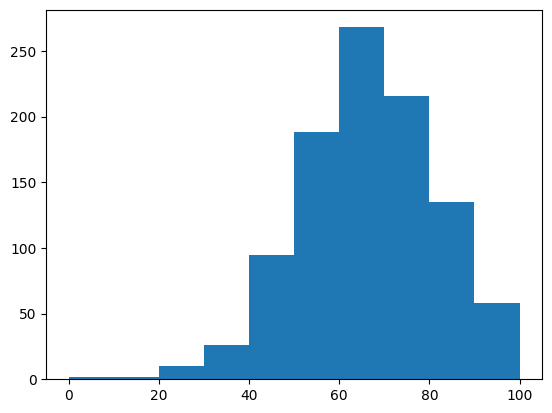

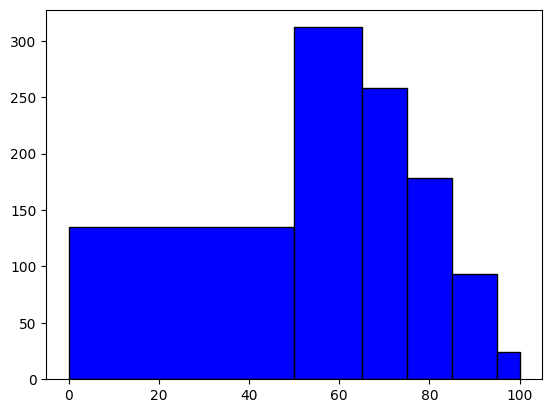

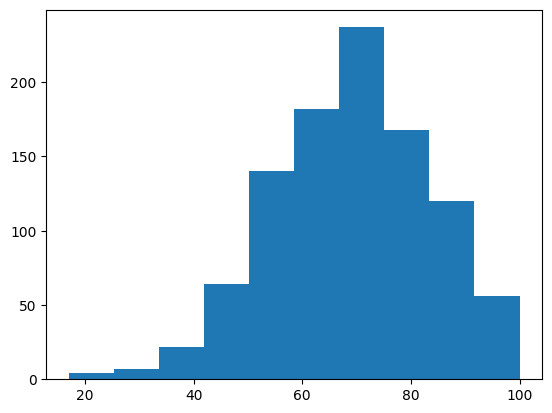

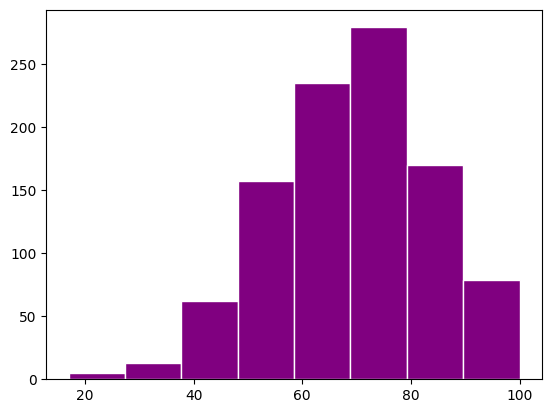

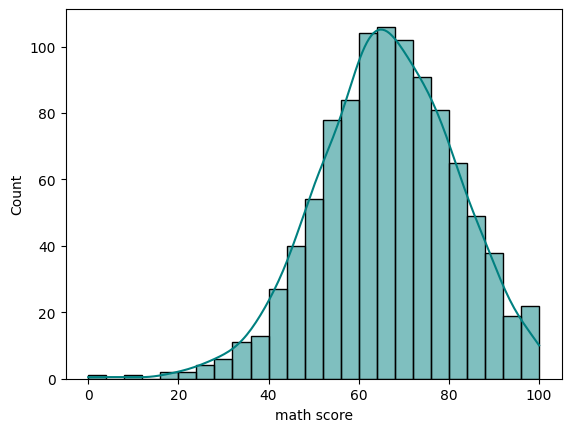

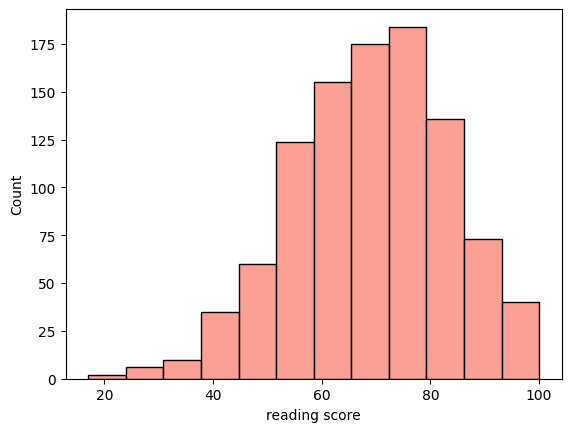

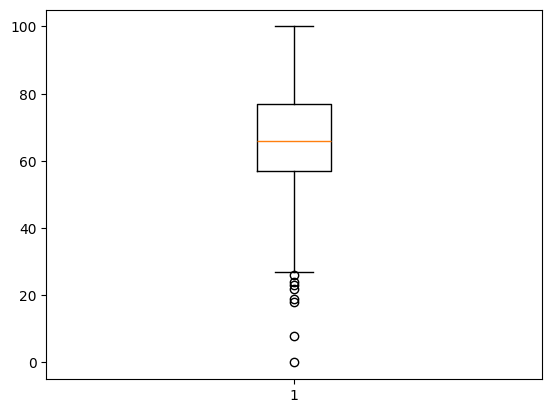

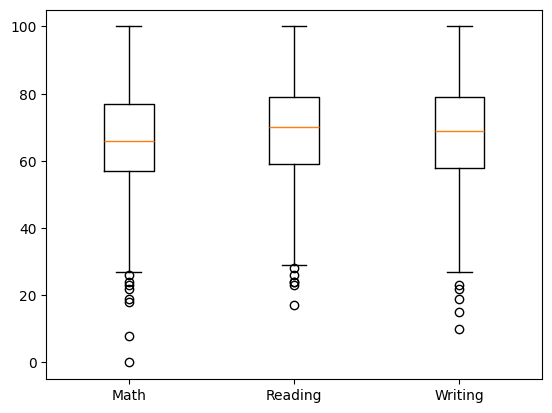

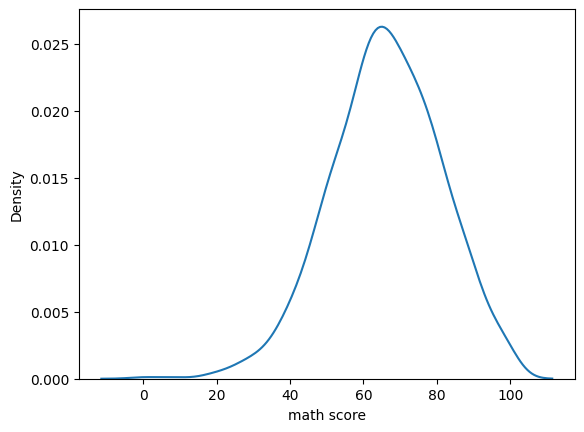

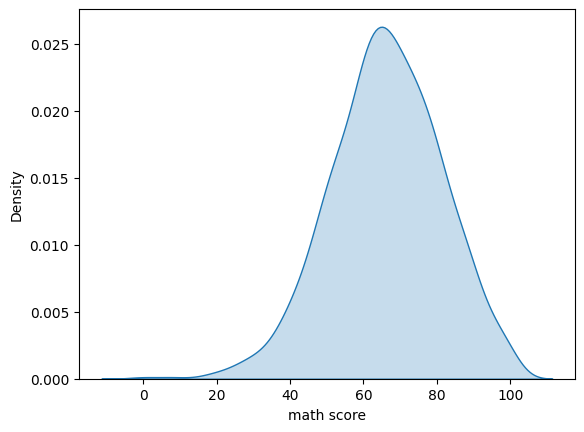

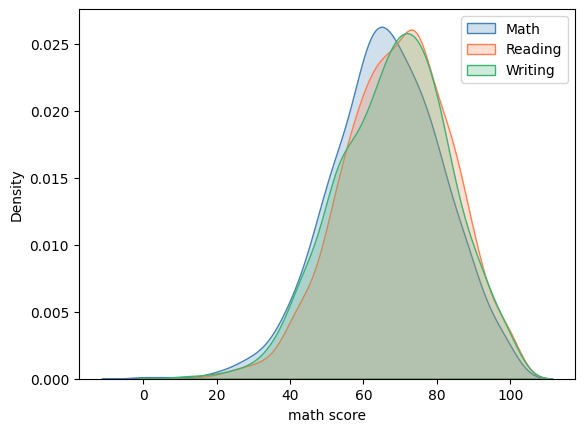

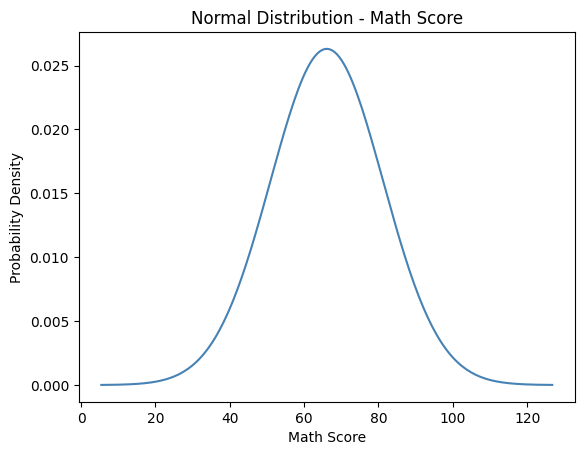

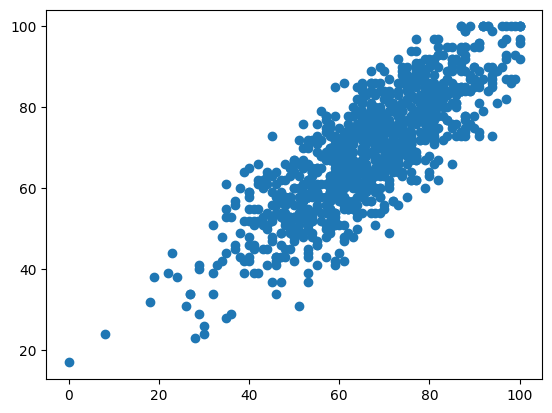

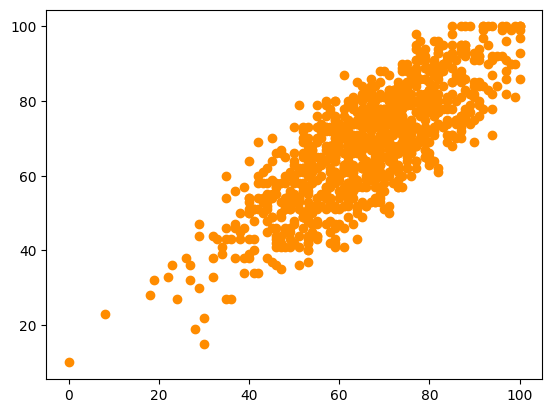

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print(dir(pd))

students = pd.read_csv('StudentsPerformance.csv')

print(students.shape)

print(students.info())

print(students.head())

# describe function will return descriptive statistics including the
# central tendency, dispersion and shape of a dataset's distribution.
print(students.describe())


# Exploratory Data Analysis
# Measures of Central Tendency / First moment business decision
print(students['math score'].mean())
print(students['math score'].median())
print(students['math score'].mode())

print(students['reading score'].mean())
print(students['reading score'].median())
print(students['reading score'].mode())

print(students['writing score'].mean())
print(students['writing score'].median())
print(students['writing score'].mode())


# Measures of Dispersion / Second moment business decision
print(students['math score'].var())
print(students['math score'].std())
math_range = max(students['math score']) - min(students['math score'])
print(math_range)

print(students['reading score'].var())
print(students['reading score'].std())
reading_range = max(students['reading score']) - min(students['reading score'])
print(reading_range)

print(students['writing score'].var())
print(students['writing score'].std())
writing_range = max(students['writing score']) - min(students['writing score'])
print(writing_range)


# Third moment business decision
print(students['math score'].skew())
print(students['reading score'].skew())
print(students['writing score'].skew())


# Fourth moment business decision
print(students['math score'].kurt())
print(students['reading score'].kurt())
print(students['writing score'].kurt())


# numpy operations
math_scores = students['math score'].values
reading_scores = students['reading score'].values
writing_scores = students['writing score'].values

print(np.mean(math_scores))
print(np.median(math_scores))
print(np.std(math_scores))
print(np.min(math_scores))
print(np.max(math_scores))
print(np.var(math_scores))


# groupby
print(students.groupby('gender')[['math score', 'reading score', 'writing score']].mean())

high_math = students[students['math score'] > 70]
print(high_math)

print(students['gender'].value_counts())
print(students['test preparation course'].value_counts())
print(students['race/ethnicity'].value_counts())


# scipy
corr, p_value = stats.pearsonr(math_scores, reading_scores)
print(corr)
print(p_value)

male_math = students[students['gender'] == 'male']['math score']
female_math = students[students['gender'] == 'female']['math score']
t_stat, p_val = stats.ttest_ind(male_math, female_math)
print(t_stat)
print(p_val)


# Probability - Normal Distribution
mu = students['math score'].mean()
sigma = students['math score'].std()
print(mu)
print(sigma)

prob_60_80 = stats.norm.cdf(80, mu, sigma) - stats.norm.cdf(60, mu, sigma)
print(prob_60_80)

prob_above_90 = 1 - stats.norm.cdf(90, mu, sigma)
print(prob_above_90)

prob_below_50 = stats.norm.cdf(50, mu, sigma)
print(prob_below_50)


# Probability - Passing probability (score > 40)
pass_math = len(students[students['math score'] > 40]) / len(students)
print(pass_math)

pass_reading = len(students[students['reading score'] > 40]) / len(students)
print(pass_reading)

pass_writing = len(students[students['writing score'] > 40]) / len(students)
print(pass_writing)


# barplot
plt.bar(height = students['math score'], x = np.arange(1, 1001, 1))
plt.show()

# Histogram
plt.hist(students['math score'])
plt.show()
plt.hist(students['math score'], bins = [0, 50, 65, 75, 85, 95, 100], color = 'blue', edgecolor = 'black')
plt.show()
plt.hist(students['reading score'])
plt.show()
plt.hist(students['reading score'], color = 'purple', edgecolor = 'white', bins = 8)
plt.show()

# Histogram using Seaborn
sns.histplot(students['math score'], kde = True, color = 'teal')
plt.show()
sns.histplot(students['reading score'], color = 'salmon', bins = 12)
plt.show()

# Boxplot
plt.figure()
plt.boxplot(students['math score'])
plt.show()

plt.figure()
plt.boxplot([students['math score'], students['reading score'], students['writing score']],
            tick_labels = ['Math', 'Reading', 'Writing'])
plt.show()

# Density Plot
sns.kdeplot(students['math score'])
plt.show()
sns.kdeplot(students['math score'], fill = True)
plt.show()

sns.kdeplot(students['math score'],    fill = True, color = 'steelblue', label = 'Math')
sns.kdeplot(students['reading score'], fill = True, color = 'coral',     label = 'Reading')
sns.kdeplot(students['writing score'], fill = True, color = 'mediumseagreen', label = 'Writing')
plt.legend()
plt.show()

# Normal Distribution Plot
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
plt.figure()
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'steelblue')
plt.title('Normal Distribution - Math Score')
plt.xlabel('Math Score')
plt.ylabel('Probability Density')
plt.show()

# Bivariate visualization
# Scatter plot
plt.scatter(x = students['math score'], y = students['reading score'])
plt.show()

plt.scatter(x = students['math score'], y = students['writing score'], color = 'darkorange')
plt.show()